### Position angles during the mission

JASMINE will monitor the Galactic Center region during its astrometry mission. The telescope optical axis is pointed toward the Galactic Center, while we need another constraint to fix the attitude of the satellite. Now, we put a simple requirement, where the sunlight that the solar array panels (SAP) receive should be maximized.

The satellite local coordinates are defined as follows. The normal vector of the SAPs is the $X$ axis, and the telescope optical axis is the $Z$ axis. Since the coordinates is a right-handed system, the $Y$ axis is naturally defined. In this system, the satellite attitude should be uniquely determined so that the Sun should reside in the $XZ$ plane of the satellite local coordinates. In this notebook, we visualize the satellite orientations or the telescope position angles during the astrometry mission.

We import required modules.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

matplotlib.rcParams['legend.frameon'] = False

In [2]:
from astropy.coordinates import SkyCoord, ICRS
from astropy.coordinates import get_body_barycentric
from astropy.coordinates import BarycentricMeanEcliptic as Ecliptic
from astropy.coordinates import CartesianRepresentation as CR
from astropy.coordinates import UnitSphericalRepresentation as SR
from astropy.time import Time

import astropy.units as u
import numpy as np
import warnings

For simplicity, the astrometry field is represented by the Galactic Center (`galcel`).

Let's check the direction toward the Galactic Center in the Ecliptic coordinates. The Galactic Center is located at (&lambda; &beta;) &simeq; (266.84&deg;, -5.536&deg;). Thus, the direction of the Galactic Center region is close to the Earth's orbital plane.

In [3]:
galcen = SkyCoord(0 * u.deg, 0 * u.deg, frame='galactic').icrs
galcen.transform_to(Ecliptic())

<SkyCoord (BarycentricMeanEcliptic: equinox=J2000.000): (lon, lat) in deg
    (266.83951978, -5.53632806)>

The observation epoch spans 1 year around 2033-01-01.

In [4]:
t0 = Time('2033-01-01 00:00:00', scale='tcb')
obstime = t0 + u.year * np.linspace(-0.5, 0.5, 10001)

The relative positions of the Earth are obtained by `get_body_barycentric`. For simplicity, we regard them as the heliocentric positions of the Earth. The unit vectors toward the Sun (`p_sun`) are calculated below.

In [5]:
Earth = get_body_barycentric('earth', obstime)
p_sun = SkyCoord((-Earth).represent_as(SR), frame='icrs')

The satellite $Z$ axis is fixed toward the Galactic Center (`galcen`), and the satellite $X$ axis is set so that the $XZ$ plane contains the Sun. Thus, the direction of the satellite $Y$ axis is uniquely determined by a cross product between `galcen` and `p_sun`.

To ensure the power supply, the sunlight incident angle to the SAPs should be smaller than 45&deg;, which determines the available epoch for the astrometry mission. The figure below illustrates the Earth's orbit in the Ecliptic coordinates around the Sun. The epochs when JASMINE can observe the Galactic Center are annotated in blue. The direction toward the Galactic Center is indicated by the orange bar.

In [6]:
p_Y = SkyCoord(CR(
  np.cross(galcen.cartesian.xyz.T, p_sun.cartesian.xyz.T).T).represent_as(SR))
phi = galcen.separation(p_sun) * np.sign(p_Y.cartesian.y)
ok = (np.abs(phi.degree - 90) < 45.0) | (np.abs(phi.degree + 90) < 45.0)

ref1 = np.argmin(np.abs(phi.degree - 90))
ref2 = np.argmin(np.abs(phi.degree + 90))

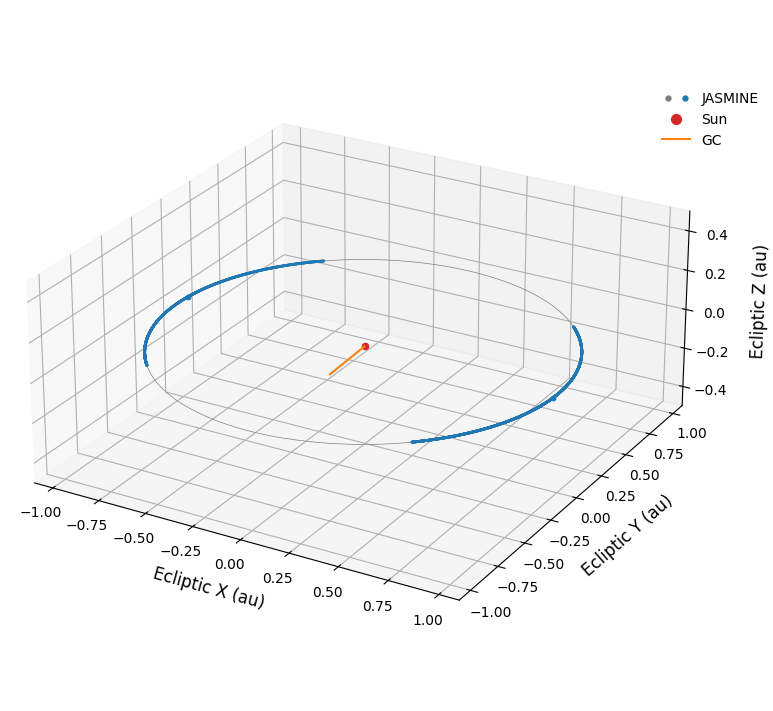

In [7]:
fig = plt.figure(
  figsize=(8, 7), layout='constrained')

ax = fig.add_subplot(projection='3d')
ax.view_init(elev=25)

ax.scatter(0, 0, 0, marker='o', color='C3', label='Sun')
ax.plot(
  *ICRS(Earth).transform_to(Ecliptic()).cartesian.xyz,
  color='gray', lw=0.5)
ax.scatter(
  *ICRS(Earth[ok]).transform_to(Ecliptic()).cartesian.xyz,
  s=1, color='C0')
ax.scatter(
  *ICRS(Earth[ref1]).transform_to(Ecliptic()).cartesian.xyz,
  s=10, color='C0')
ax.scatter(
  *ICRS(Earth[ref2]).transform_to(Ecliptic()).cartesian.xyz,
  s=10, color='C0')

ax.quiver(
  0, 0, 0, *galcen.transform_to(Ecliptic()).cartesian.xyz,
  color='C1', length=0.3,
  arrow_length_ratio=0, normalize=True)

ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])
ax.set_zlim([-0.5, 0.5])
ax.set_aspect('equal')

ax.set_xlabel('Ecliptic X (au)', fontsize=12, labelpad=10)
ax.set_ylabel('Ecliptic Y (au)', fontsize=12, labelpad=10)
ax.set_zlabel('Ecliptic Z (au)', fontsize=12, labelpad=10)

hg = ax.scatter([], [], [], s=50, marker='.', color='gray')
hb = ax.scatter([], [], [], s=50, marker='.', color='C0')
hs = ax.scatter([], [], [], s=50, marker='o', color='C3')
ha = ax.plot([], [], lw=1.5, color='C1')[0]

ax.legend(
  [(hg, hb), hs, ha], ['JASMINE', 'Sun', 'GC'], fontsize=10,
  loc='upper right', bbox_to_anchor=(1.10, 0.9),
  handler_map={tuple: HandlerTuple(ndivide=None, pad=0.5)})

plt.show()

The directions of the satellite $Y$ axis are illustrated in the ICRS coordinates. The satellite orientation is flipped between two observation seasons, and the $Y$ axis show a systematic drift during a single season. The two red vectors show the $Y$ axis at the parallax apex epochs.

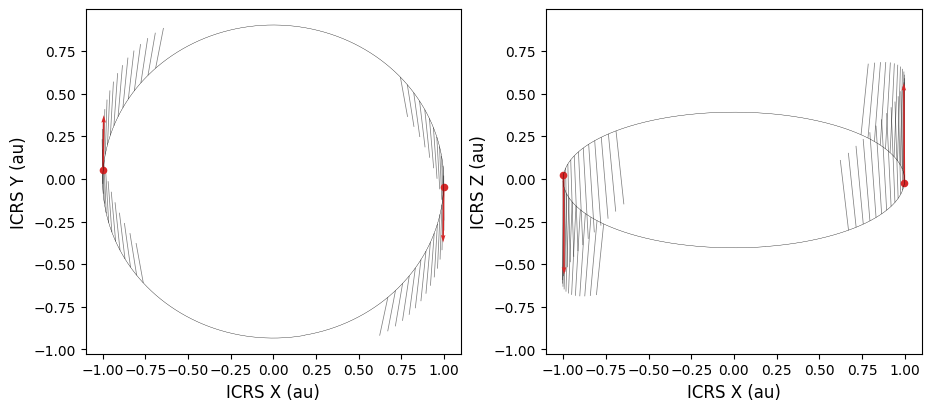

In [8]:
p_Y = SkyCoord(
  CR(np.cross(p_sun.cartesian.xyz.T, galcen.cartesian.xyz.T).T))

fig, axes = plt.subplots(
  1, 2, figsize=(9.2, 4), layout='constrained')

ax = axes[0]
ax.plot(
  Earth.x.value, Earth.y.value, color='black',
  lw=0.25)
ax.quiver(
  Earth.x.value[ok][::100], Earth.y.value[ok][::100],
  p_Y.cartesian.x.value[ok][::100], p_Y.cartesian.y.value[ok][::100],
  angles='xy', scale_units='xy', scale=1.5, alpha=0.5,
  width=0.002, headwidth=1, headlength=0, zorder=-10)
ax.quiver(
  Earth.x.value[ref1], Earth.y.value[ref1],
  p_Y.cartesian.x.value[ref1], p_Y.cartesian.y.value[ref1],
  angles='xy', scale_units='xy', color='C3',
  scale=1.5, width=0.004)
ax.quiver(
  Earth.x.value[ref2], Earth.y.value[ref2],
  p_Y.cartesian.x.value[ref2], p_Y.cartesian.y.value[ref2],
  angles='xy', scale_units='xy', color='C3',
  scale=1.5, width=0.004)
ax.scatter(
  Earth.x[ref1], Earth.y[ref1], color='C3', s=20)
ax.scatter(
  Earth.x[ref2], Earth.y[ref2], color='C3', s=20)

ax.set_aspect('equal')
ax.set_xlabel('ICRS X (au)', fontsize=12)
ax.set_ylabel('ICRS Y (au)', fontsize=12)

ax = axes[1]
ax.plot(
  Earth.x.value, Earth.z.value, color='black',
  lw=0.25)
ax.quiver(
  Earth.x.value[ok][::100], Earth.z.value[ok][::100],
  p_Y.cartesian.x.value[ok][::100], p_Y.cartesian.z.value[ok][::100],
  angles='xy', scale_units='xy', scale=1.5, alpha=0.5,
  width=0.002, headwidth=1, headlength=0, zorder=-10)
ax.quiver(
  Earth.x.value[ref1], Earth.z.value[ref1],
  p_Y.cartesian.x.value[ref1], p_Y.cartesian.z.value[ref1],
  angles='xy', scale_units='xy', color='C3',
  scale=1.5, width=0.004)
ax.quiver(
  Earth.x.value[ref2], Earth.z.value[ref2],
  p_Y.cartesian.x.value[ref2], p_Y.cartesian.z.value[ref2],
  angles='xy', scale_units='xy', color='C3',
  scale=1.5, width=0.004)
ax.scatter(
  Earth.x[ref1], Earth.z[ref1], color='C3', s=20)
ax.scatter(
  Earth.x[ref2], Earth.z[ref2], color='C3', s=20)

ax.set_xlim(axes[0].get_xlim())
ax.set_ylim(axes[0].get_ylim())
ax.set_xlabel('ICRS X (au)', fontsize=12)
ax.set_ylabel('ICRS Z (au)', fontsize=12)

plt.show()

The position angles of the satellite $Y$ axis are evaluated around the Galactic Center region. The position angle consistently increases during the mission, spanning around &pm;5&deg; around the position angle at the parallax apex in each season. We should take into account this position angle drift for precise focal plane calibration.

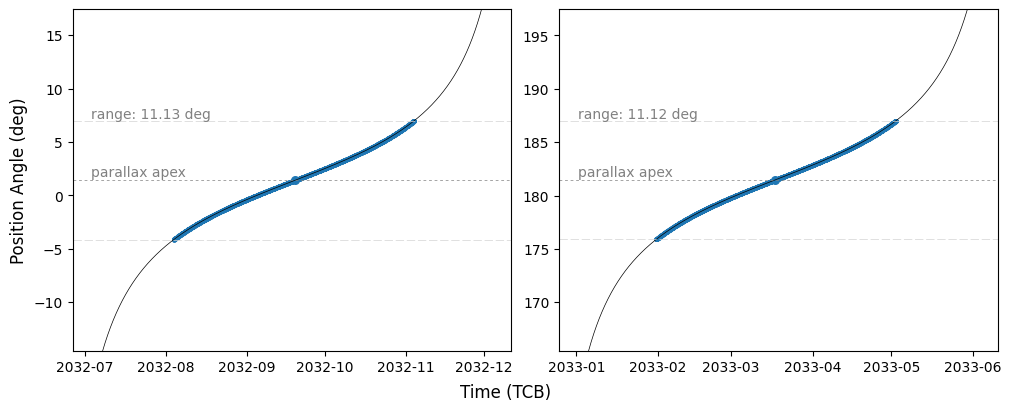

In [9]:
theta = galcen.position_angle(p_Y).degree
theta = np.where(theta > theta[-1], theta - 360, theta)

fig, axes = plt.subplots(
  1, 2, figsize=(10, 4), layout='constrained')

ax = axes[0]
tr = np.abs(theta - theta[ref1]) < 20
ax.plot(
  obstime.datetime[tr], theta[tr],
  lw=0.5, color='black')
ax.scatter(
  obstime[ok & tr].datetime, theta[ok & tr],
  s=5, color='C0')
ax.scatter(
  obstime[ref1].datetime, theta[ref1],
  s=30, color='C0')

ax.axhline(
  theta[ok & tr].max(), color='lightgray', lw=0.5, dashes=(12, 4))
ax.axhline(
  theta[ok & tr].min(), color='lightgray', lw=0.5, dashes=(12, 4))
ax.text(
  obstime.datetime[ref1 - 2150], 7.2,
  rf'range: {np.ptp(theta[ok & tr]):.2f} deg', color='gray', fontsize=10)

ax.text(
  obstime.datetime[ref1 - 2150], 1.8,
  'parallax apex', color='gray', fontsize=10)
ax.axhline(
  theta[ref1], color='gray', lw=0.5, dashes=(4, 4))

ax.set_ylabel('Position Angle (deg)', fontsize=12)
ax.set_ylim([theta[ref1] - 16, theta[ref1] + 16])

ax = axes[1]
tr = np.abs(theta - theta[ref2]) < 20

ax.plot(
  obstime.datetime[tr], theta[tr],
  lw=0.5, color='black')
ax.scatter(
  obstime[ok & tr].datetime, theta[ok & tr],
  s=5, color='C0')
ax.scatter(
  obstime[ref2].datetime, theta[ref2],
  s=30, color='C0')

ax.axhline(
  theta[ok & tr].max(), color='lightgray', lw=0.5, dashes=(12, 4))
ax.axhline(
  theta[ok & tr].min(), color='lightgray', lw=0.5, dashes=(12, 4))
ax.text(
  obstime.datetime[ref2 - 2050], 187.2,
  rf'range: {np.ptp(theta[ok & tr]):.2f} deg', color='gray', fontsize=10)

ax.text(
  obstime.datetime[ref2 - 2050], 181.8,
  'parallax apex', color='gray', fontsize=10)
ax.axhline(
  theta[ref2], color='gray', lw=0.5, dashes=(4, 4))
ax.set_ylim([theta[ref2] - 16, theta[ref2] + 16])

fig.supxlabel('Time (TCB)', fontsize=12)

plt.show()